In [3]:
import glob
from utilities import utils
from tasks import dmj

dj_bl = sorted(p for p in glob.glob("data/keypoints/dj/*.txt")
               if "world" not in p.lower() and "UL" not in p.upper())
dj_ul = sorted(p for p in glob.glob("data/keypoints/dj/*.txt")
               if "world" not in p.lower() and "UL" in p.upper())
subjects = utils.read_list('dj_data')

jh, ft, ct = dmj.get_metrics(dj_bl, dj_ul, subjects, ptm='height')
jh

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Jump height,Drop jump bilateral,height,Force plates,3.00,0.83,0.80
1,Jump height,Drop jump unilateral,height,Force plates,2.29,0.67,0.62


In [4]:
o1, o2 = peaks[-2:]
jump_h = (max(rep[o1:o2]) - rep[o2]) / 10

NameError: name 'peaks' is not defined

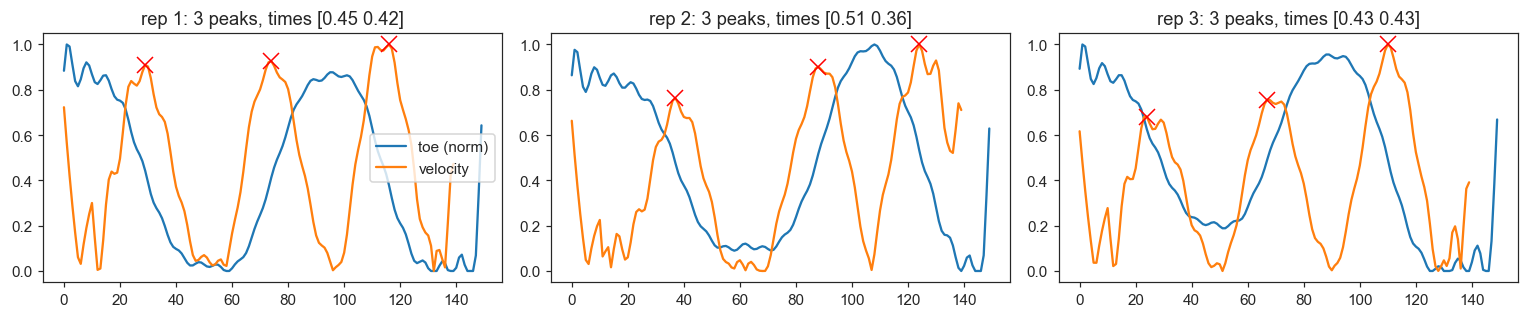

In [ ]:
import numpy as np
from scipy.signal import savgol_filter, resample

from utilities.utils import time_from_velocity, scale_filter
import matplotlib.pyplot as plt

fp = next(p for p in dj_bl if "P03" in p)
toe_y = dmj._toe_signal(fp)
scales = dmj._ptm_scale(dj_bl, "height", True, 1920, 1080, 30)
starts = dmj.OPENPOSE_OP_SEGS["bl"][0]

fig, axs = plt.subplots(1, 3, figsize=(14,3), dpi=110)
for i, s0 in enumerate(starts):
    rep = dmj._toe_rep_window(toe_y, int(s0)) * scales["P03"]
    rep = resample(rep, 150); rep = np.where(rep>0, rep, 0)
    vel = abs(savgol_filter(np.gradient(rep), 21, 2))[:-10]
    vel, _ = scale_filter(vel)
    times, peaks = time_from_velocity(vel, 0.5, 15)
    axs[i].plot(rep/rep.max(), label="toe (norm)")
    axs[i].plot(vel, label="velocity")
    axs[i].plot(peaks, vel[peaks], "rx", ms=10)
    axs[i].set_title(f"rep {i+1}: {len(peaks)} peaks, times {times}")
axs[0].legend()
plt.tight_layout(); plt.show()

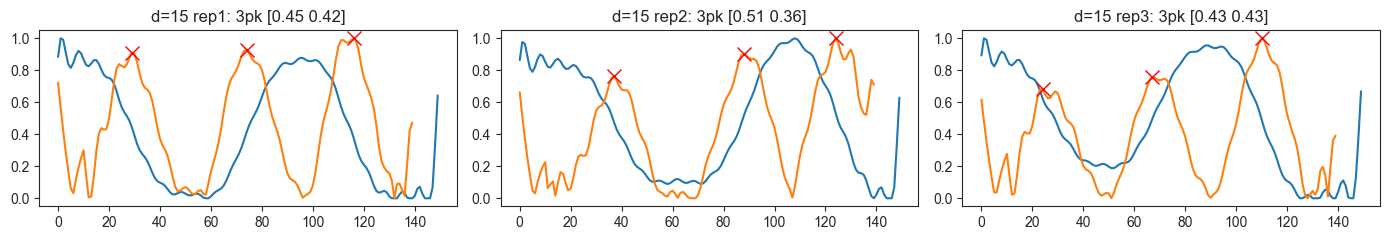

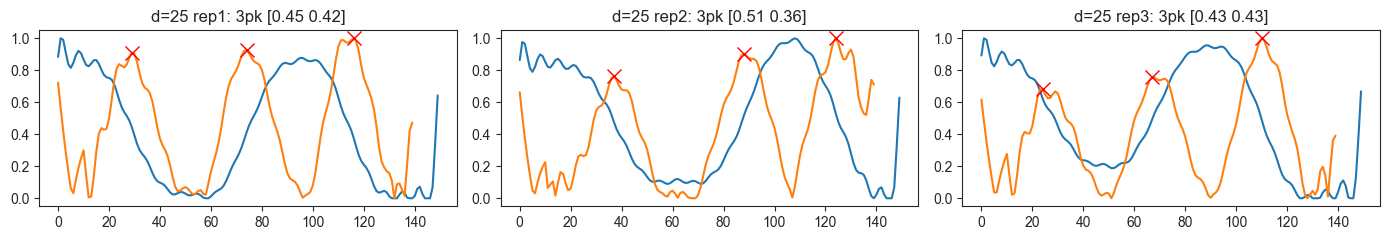

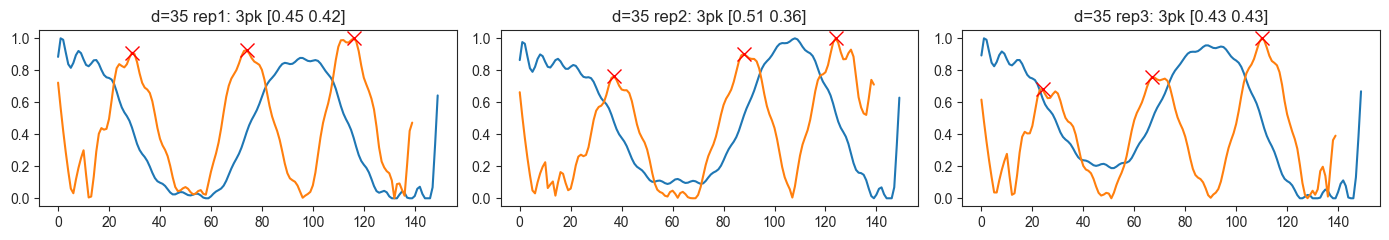

In [ ]:
import numpy as np
from scipy.signal import savgol_filter, resample
from tasks import dmj as dj
from utilities.utils import time_from_velocity, scale_filter
import matplotlib.pyplot as plt

fp = next(p for p in dj_bl if "P03" in p)
toe_y = dj._toe_signal(fp)
scales = dj._ptm_scale(dj_bl, "height", True, 1920, 1080, 30)
starts = dj.OPENPOSE_OP_SEGS["bl"][0]

for d_try in [15, 25, 35]:
    fig, axs = plt.subplots(1, 3, figsize=(14,2.5), dpi=100)
    for i, s0 in enumerate(starts):
        rep = dj._toe_rep_window(toe_y, int(s0)) * scales["P03"]
        rep = resample(rep, 150); rep = np.where(rep>0, rep, 0)
        vel = abs(savgol_filter(np.gradient(rep), 21, 2))[:-10]
        vel, _ = scale_filter(vel)
        times, peaks = time_from_velocity(vel, 0.5, d_try)
        axs[i].plot(rep/rep.max()); axs[i].plot(vel)
        axs[i].plot(peaks, vel[peaks], "rx", ms=10)
        axs[i].set_title(f"d={d_try} rep{i+1}: {len(peaks)}pk {times}")
    plt.tight_layout(); plt.show()

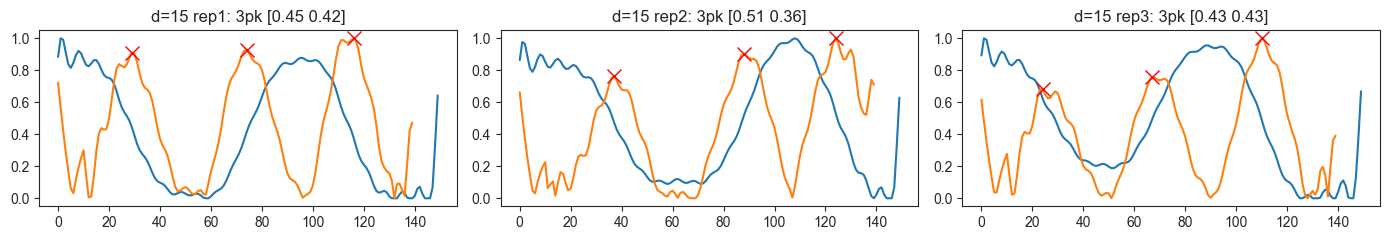

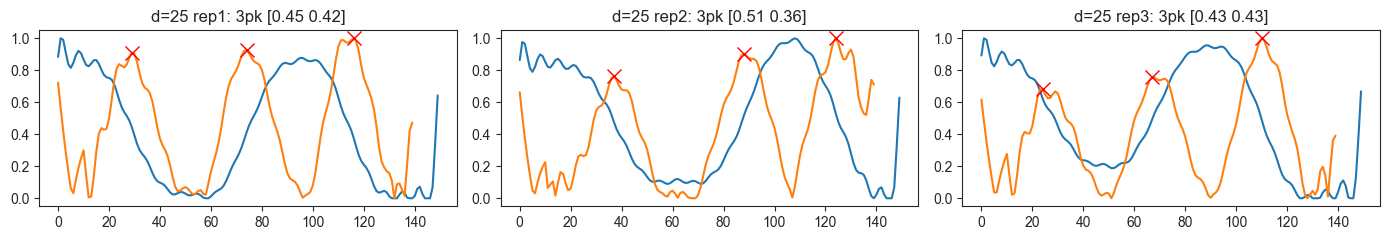

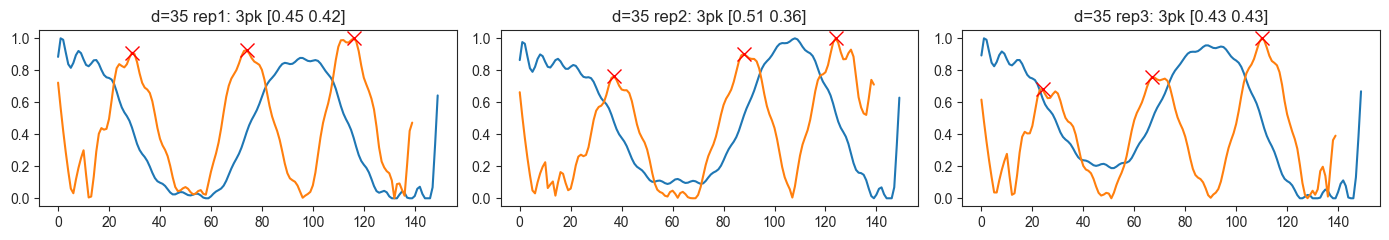

In [ ]:
import numpy as np
from scipy.signal import savgol_filter, resample
from tasks import dmj as dj
from utilities.utils import time_from_velocity, scale_filter
import matplotlib.pyplot as plt

fp = next(p for p in dj_bl if "P03" in p)
toe_y = dj._toe_signal(fp)
scales = dj._ptm_scale(dj_bl, "height", True, 1920, 1080, 30)
starts = dj.OPENPOSE_OP_SEGS["bl"][0]

for d_try in [15, 25, 35]:
    fig, axs = plt.subplots(1, 3, figsize=(14,2.5), dpi=100)
    for i, s0 in enumerate(starts):
        rep = dj._toe_rep_window(toe_y, int(s0)) * scales["P03"]
        rep = resample(rep, 150); rep = np.where(rep>0, rep, 0)
        vel = abs(savgol_filter(np.gradient(rep), 21, 2))[:-10]
        vel, _ = scale_filter(vel)
        times, peaks = time_from_velocity(vel, 0.5, d_try)
        axs[i].plot(rep/rep.max()); axs[i].plot(vel)
        axs[i].plot(peaks, vel[peaks], "rx", ms=10)
        axs[i].set_title(f"d={d_try} rep{i+1}: {len(peaks)}pk {times}")
    plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
from scipy.signal import savgol_filter, resample
from tasks import dmj as dj
from utilities.utils import time_from_velocity, scale_filter

# MMC heights for P03 bilateral
fp = next(p for p in dj_bl if "P03" in p)
toe_y = dj._toe_signal(fp)
scales = dj._ptm_scale(dj_bl, "height", True, 1920, 1080, 30)
starts = dj.OPENPOSE_OP_SEGS["bl"][0]
print("P03 scale:", round(scales["P03"],3), "mm/px")
for i, s0 in enumerate(starts):
    rep = dj._toe_rep_window(toe_y, int(s0)) * scales["P03"]
    rep = resample(rep, 150); rep = np.where(rep>0, rep, 0)
    vel = abs(savgol_filter(np.gradient(rep), 21, 2))[:-10]
    vel, _ = scale_filter(vel)
    times, peaks = time_from_velocity(vel, 0.5, 15)
    o1, o2 = peaks[-2:]
    h = (max(rep[o1:o2]) - rep[o2])/10
    print(f"rep{i+1}: peaks {list(peaks)}  height {h:.1f}cm  (window max {rep.max()/10:.1f}cm)")

# force-plate heights for P03 bilateral
fp_jh, fp_ct, fp_ft = dj._fp_perf(subjects, "bl")
print("force P03:", fp_jh["P03"])

P03 scale: 4.275 mm/px
rep1: peaks [np.int64(29), np.int64(74), np.int64(116)]  height 17.0cm  (window max 34.0cm)
rep2: peaks [np.int64(37), np.int64(88), np.int64(124)]  height 18.1cm  (window max 38.8cm)
rep3: peaks [np.int64(24), np.int64(67), np.int64(110)]  height 19.4cm  (window max 41.8cm)
force P03: [np.float64(27.08), np.float64(28.24), np.float64(29.43)]


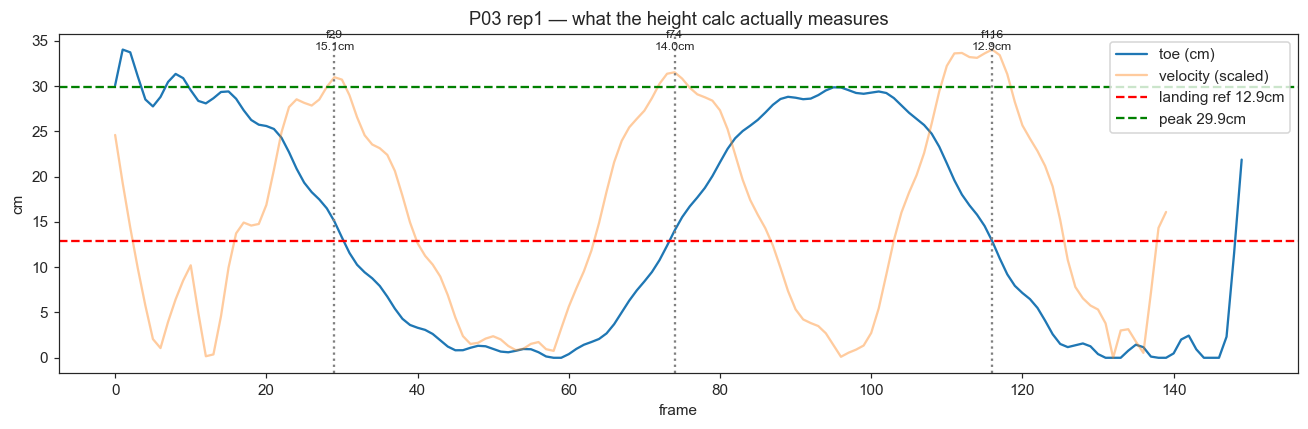

In [ ]:
import numpy as np
from scipy.signal import savgol_filter, resample
from tasks import dmj as dj
from utilities.utils import time_from_velocity, scale_filter
import matplotlib.pyplot as plt

fp = next(p for p in dj_bl if "P03" in p)
toe_y = dj._toe_signal(fp)
scales = dj._ptm_scale(dj_bl, "height", True, 1920, 1080, 30)
s0 = dj.OPENPOSE_OP_SEGS["bl"][0][0]
rep = dj._toe_rep_window(toe_y, int(s0)) * scales["P03"]
rep = resample(rep, 150); rep = np.where(rep>0, rep, 0)
vel = abs(savgol_filter(np.gradient(rep), 21, 2))[:-10]
vel, _ = scale_filter(vel)
times, peaks = time_from_velocity(vel, 0.5, 15)

plt.figure(figsize=(12,4), dpi=110)
plt.plot(rep/10, label="toe (cm)")
plt.plot(np.array(vel)*rep.max()/10, alpha=0.4, label="velocity (scaled)")
for p in peaks:
    plt.axvline(p, color="grey", ls=":")
    plt.text(p, rep.max()/10, f"f{p}\n{rep[p]/10:.1f}cm", fontsize=8, ha="center")
o1, o2 = peaks[-2:]
plt.axhline(rep[o2]/10, color="red", ls="--", label=f"landing ref {rep[o2]/10:.1f}cm")
plt.axhline(max(rep[o1:o2])/10, color="green", ls="--", label=f"peak {max(rep[o1:o2])/10:.1f}cm")
plt.title("P03 rep1 — what the height calc actually measures")
plt.legend(); plt.xlabel("frame"); plt.ylabel("cm"); plt.tight_layout(); plt.show()

In [2]:
import glob
from utilities import utils
from tasks import dmj as dj

dj_bl = sorted(p for p in glob.glob("data/keypoints/dj/*.txt")
               if "world" not in p.lower() and "UL" not in p.upper())
dj_ul = sorted(p for p in glob.glob("data/keypoints/dj/*.txt")
               if "world" not in p.lower() and "UL" in p.upper())
subjects = utils.read_list('dj_data')
print(len(dj_bl), "bl /", len(dj_ul), "ul")

16 bl / 16 ul


In [3]:
import numpy as np
from scipy.signal import savgol_filter, resample
from tasks import dmj as dj
from utilities.utils import time_from_velocity, scale_filter

fp = next(p for p in dj_bl if "P03" in p)
toe_y = dj._toe_signal(fp)
scales = dj._ptm_scale(dj_bl, "height", True, 1920, 1080, 30)
starts = dj.OPENPOSE_OP_SEGS["bl"][0]
for i, s0 in enumerate(starts):
    rep = dj._toe_rep_window(toe_y, int(s0)) * scales["P03"]
    rep = resample(rep, 150); rep = np.where(rep>0, rep, 0)
    vel = abs(savgol_filter(np.gradient(rep), 21, 2))[:-10]
    vel, _ = scale_filter(vel)
    times, peaks = time_from_velocity(vel, 0.5, 15)
    o1, o2 = peaks[-2:]
    lo = max(o1-5, 0); seg = rep[lo:o2+1]
    pk = int(np.argmax(seg))
    h = (seg[pk] - seg[:pk+1].min())/10
    print(f"rep{i+1}: {h:.1f}cm")
print("force P03:", dj._fp_perf(subjects, "bl")[0]["P03"])

rep1: 22.4cm
rep2: 26.0cm
rep3: 25.6cm
force P03: [np.float64(27.08), np.float64(28.24), np.float64(29.43)]


In [4]:
jh, ft, ct = dj.get_metrics(dj_bl, dj_ul, subjects, ptm='height')
jh

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Jump height,Drop jump bilateral,height,Force plates,3.00,0.83,0.80
1,Jump height,Drop jump unilateral,height,Force plates,2.29,0.67,0.62


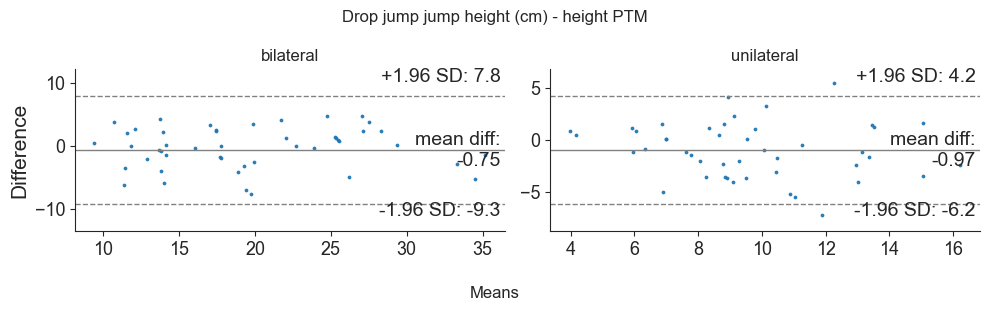

In [5]:
dj.ba_plots(dj_bl, dj_ul, subjects, ptm='height')

In [6]:
jh_g = dj.get_metrics(dj_bl, dj_ul, subjects, ptm='gravity')
jh_g

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Jump height,Drop jump bilateral,gravity,Force plates,5.67,0.86,0.60
1,Jump height,Drop jump unilateral,gravity,Force plates,2.22,0.75,0.56


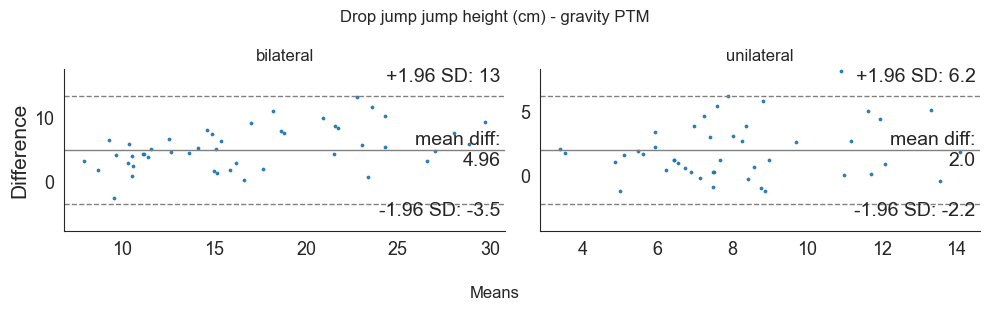

In [8]:
dj.ba_plots(dj_bl, dj_ul, subjects, ptm='gravity', plot='jump height')

In [9]:
ft

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Flight time,Drop jump bilateral,height,Force plates,0.11,0.80,0.37
1,Flight time,Drop jump unilateral,height,Force plates,0.07,0.09,0.05


In [ ]:
ct

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Contact time,Drop jump bilateral,height,Force plates,0.13,0.50,0.34
1,Contact time,Drop jump unilateral,height,Force plates,0.10,0.46,0.49


: 